<a href="https://colab.research.google.com/github/moawinds/BengKod_Alwi/blob/main/UTS_Bengkod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Data Understanding & EDA**

Import Library dan Load Data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Untuk mengabaikan pesan peringatan

# Load dataset (Sesuaikan nama file dengan yang Anda unduh)
# Misalnya: df = pd.read_csv('train.csv')
df = pd.read_csv('airline_passenger_satisfaction.csv')

# Menghapus kolom 'Unnamed: 0' dan 'id' karena hanya berupa identifier/index yang tidak relevan untuk analisis
if 'Unnamed: 0' in df.columns:
    df = df.drop(['Unnamed: 0', 'id'], axis=1)

1.1 Eksplorasi awal & identifikasi fitur (Bobot 5%)

In [ ]:
# Tampilkan 5 baris pertama
print("--- 5 Baris Pertama Dataset ---")
display(df.head())

# Informasi dataset (jumlah baris, kolom, dan tipe data)
print("\n--- Informasi Dataset ---")
df.info()

# Statistik deskriptif
print("\n--- Statistik Deskriptif ---")
display(df.describe(include='all'))

# --- Pengelompokan Fitur ---
# Berdasarkan struktur data Airline Passenger Satisfaction
fitur_kategorikal = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
fitur_kontinu = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

# Fitur rating umumnya memiliki rentang nilai 0-5
fitur_rating = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking',
                'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
                'Inflight entertainment', 'On-board service', 'Leg room service',
                'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']

target = 'Satisfaction'

--- 5 Baris Pertama Dataset ---


,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied



--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129880 non-null  int64  
 1   Gender                                  129880 non-null  object 
 2   Age                                     129880 non-null  int64  
 3   Customer Type                           129880 non-null  object 
 4   Type of Travel                          129880 non-null  object 
 5   Class                                   129880 non-null  object 
 6   Flight Distance                         129880 non-null  int64  
 7   Departure Delay                         129880 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129880 non-null  int64  
 10  Ease of Online Bo

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
count,129880.000000,129880,129880.000000,129880,129880,129880,129880.000000,129880.000000,129487.000000,129880.000000,...,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880
unique,NaN,2,NaN,2,2,3,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,Female,NaN,Returning,Business,Business,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Neutral or Dissatisfied
freq,NaN,65899,NaN,106100,89693,62160,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73452
mean,64940.500000,NaN,39.427957,NaN,NaN,NaN,1190.316392,14.713713,15.091129,3.057599,...,3.383023,3.441361,3.350878,3.286326,3.204774,3.642193,2.728696,3.358077,3.632114,NaN
std,37493.270818,NaN,15.119360,NaN,NaN,NaN,997.452477,38.071126,38.465650,1.526741,...,1.287099,1.319289,1.316252,1.313682,1.329933,1.176669,1.329340,1.334049,1.180025,NaN
min,1.000000,NaN,7.000000,NaN,NaN,NaN,31.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN
25%,32470.750000,NaN,27.000000,NaN,NaN,NaN,414.000000,0.000000,0.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000,NaN
50%,64940.500000,NaN,40.000000,NaN,NaN,NaN,844.000000,0.000000,0.000000,3.000000,...,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000,NaN
75%,97410.250000,NaN,51.000000,NaN,NaN,NaN,1744.000000,12.000000,13.000000,4.000000,...,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000,NaN


1.2 Identifikasi missing value & duplikasi data (Bobot 5%)

In [ ]:
# Menghitung persentase nilai kosong (missing values)
print("--- Persentase Missing Value ---")
missing_val = df.isnull().sum()
missing_percent = (missing_val / len(df)) * 100
missing_df = pd.DataFrame({'Missing Value': missing_val, 'Persentase (%)': missing_percent})
display(missing_df[missing_df['Missing Value'] > 0]) # Hanya menampilkan kolom yang ada missing value-nya

# Pengecekan data duplikat
jumlah_duplikat = df.duplicated().sum()
print(f"\nJumlah data duplikat dalam dataset: {jumlah_duplikat}")

--- Persentase Missing Value ---


,Missing Value,Persentase (%)
Arrival Delay,393,0.302587



Jumlah data duplikat dalam dataset: 0


1.3 Visualisasi distribusi data (Bobot 5%)

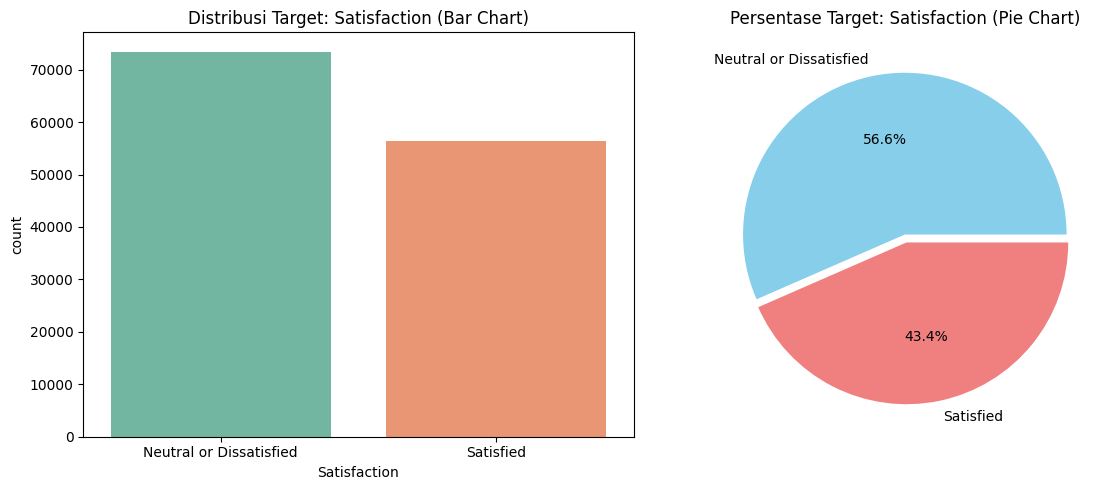

Kolom 'Inflight wifi service' tidak ditemukan.


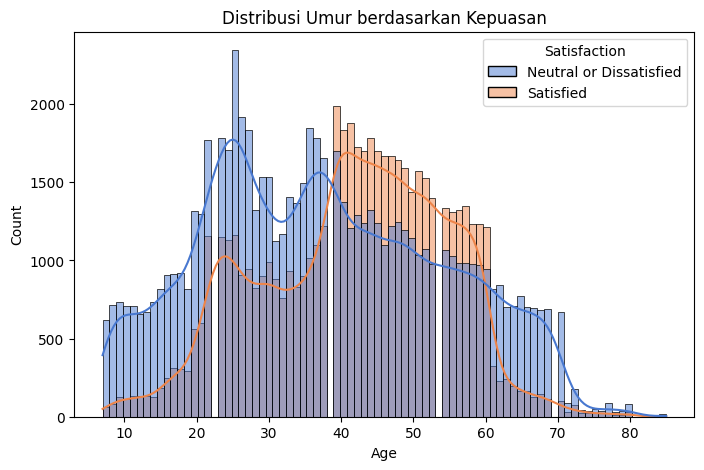

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Menentukan kolom target otomatis (mengatasi masalah huruf besar/kecil)
if 'satisfaction' in df.columns:
    target = 'satisfaction'
elif 'Satisfaction' in df.columns:
    target = 'Satisfaction'
else:
    print("Error: Kolom target tidak ditemukan. Cek df.columns!")

# 2. Visualisasi Distribusi Target (Satisfaction)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
sns.countplot(data=df, x=target, ax=ax[0], palette='Set2')
ax[0].set_title('Distribusi Target: Satisfaction (Bar Chart)')

# Pie chart
df[target].value_counts().plot.pie(autopct='%1.1f%%', ax=ax[1], colors=['skyblue', 'lightcoral'], explode=[0, 0.05])
ax[1].set_title('Persentase Target: Satisfaction (Pie Chart)')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

# 3. Visualisasi Distribusi Fitur Rating (Contoh: Inflight wifi service)
# Pastikan nama kolom 'Inflight wifi service' benar-benar ada di dataset
if 'Inflight wifi service' in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='Inflight wifi service', hue=target, palette='viridis')
    plt.title('Distribusi Rating: Inflight wifi service berdasarkan Kepuasan')
    plt.show()
else:
    print("Kolom 'Inflight wifi service' tidak ditemukan.")

# 4. Visualisasi Distribusi Fitur Kontinu (Contoh: Age)
if 'Age' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x='Age', hue=target, kde=True, palette='muted')
    plt.title('Distribusi Umur berdasarkan Kepuasan')
    plt.show()
else:
    print("Kolom 'Age' tidak ditemukan.")

1.4 Analisis outlier & korelasi (Bobot 5%)

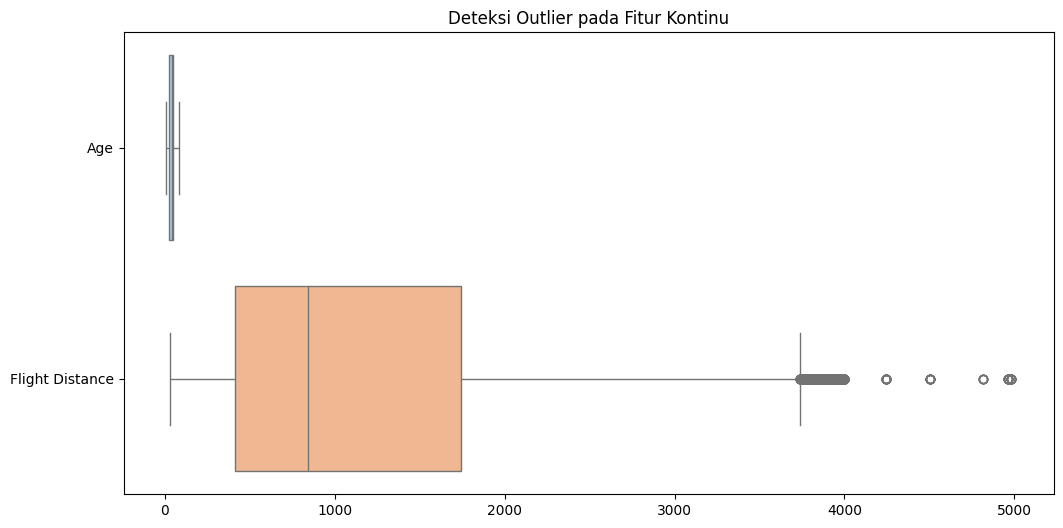

Analisis Outlier: Terdapat titik-titik di luar batas kumis (whisker) yang menandakan adanya outlier, terutama pada fitur Delay penerbangan dan Jarak penerbangan.


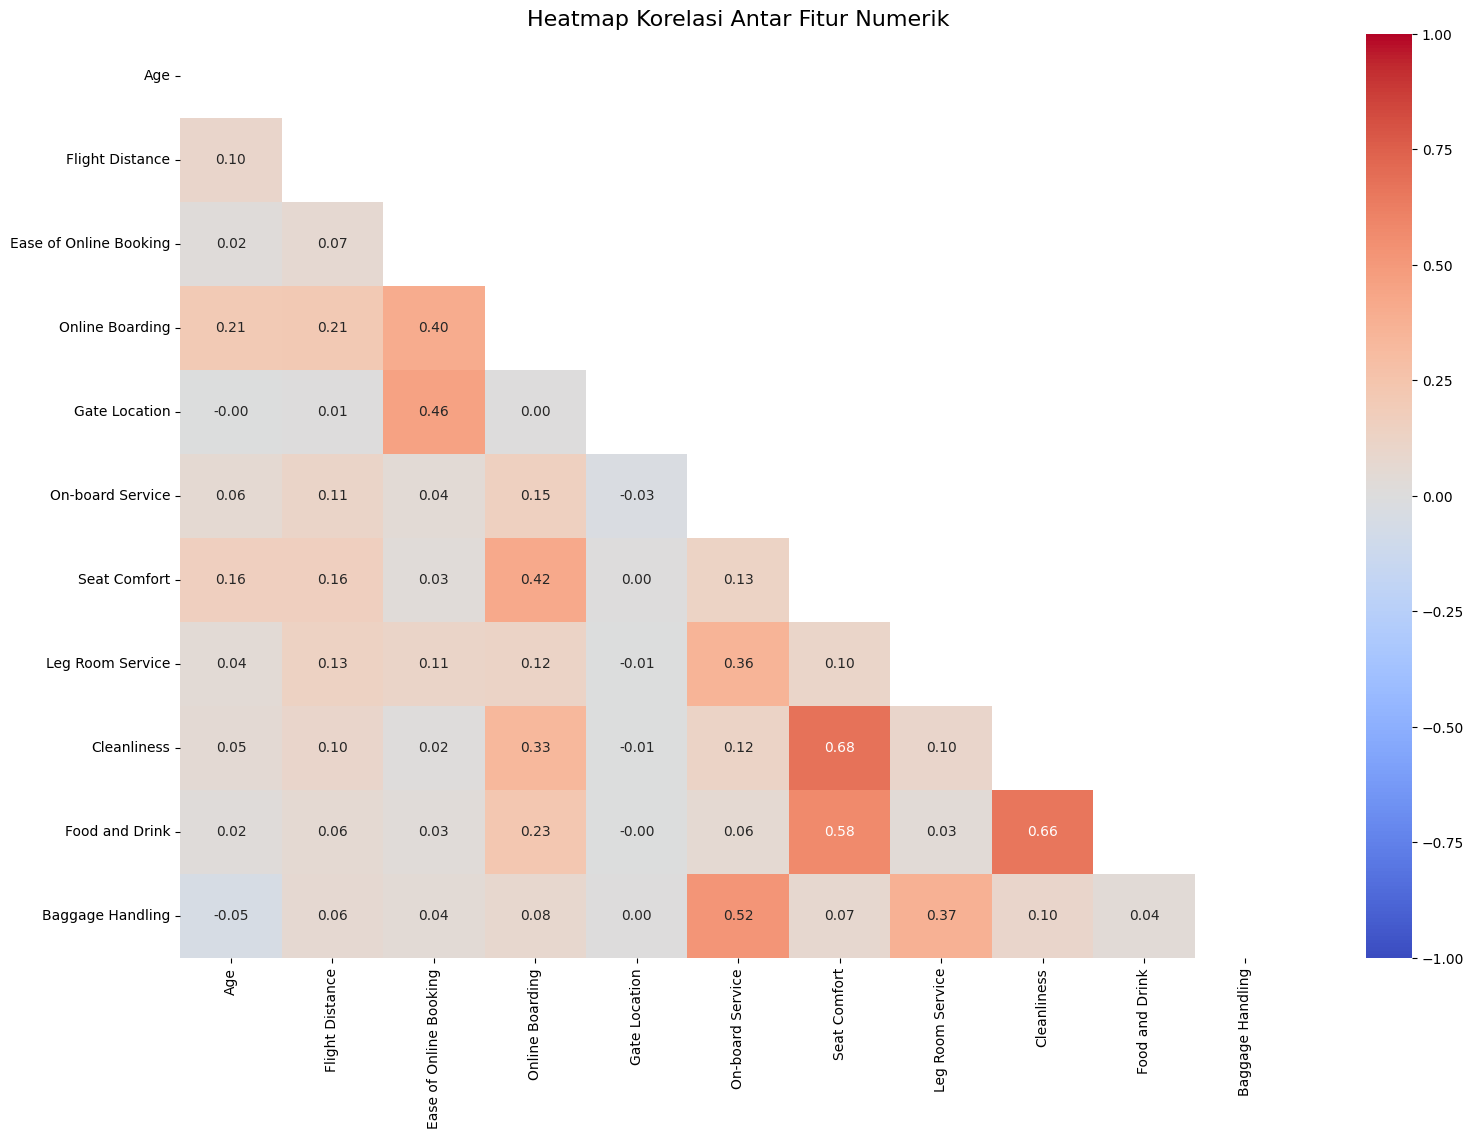

Analisis Korelasi: Perhatikan nilai korelasi yang mendekati 1. 'Departure Delay in Minutes' dan 'Arrival Delay in Minutes' biasanya memiliki korelasi yang sangat tinggi, mengindikasikan adanya redundansi fitur.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Mendefinisikan ulang fitur (berjaga-jaga jika belum di-run di cell sebelumnya)
fitur_kontinu_awal = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
fitur_rating_awal = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking',
                     'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
                     'Inflight entertainment', 'On-board service', 'Leg room service',
                     'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']

# 2. Memfilter fitur agar otomatis menyesuaikan dengan nama kolom di dataset Anda (menghindari KeyError)
# Jika nama kolom di dataset memakai huruf kecil, kita sesuaikan.
kolom_dataset = df.columns.tolist()

fitur_kontinu = [col for col in kolom_dataset if col.lower() in [f.lower() for f in fitur_kontinu_awal]]
fitur_rating = [col for col in kolom_dataset if col.lower() in [f.lower() for f in fitur_rating_awal]]

# ==========================================
# BAGIAN A: Deteksi Outlier (Boxplot)
# ==========================================
if len(fitur_kontinu) > 0:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df[fitur_kontinu], orient='h', palette='pastel')
    plt.title('Deteksi Outlier pada Fitur Kontinu')
    plt.show()
    print("Analisis Outlier: Terdapat titik-titik di luar batas kumis (whisker) yang menandakan adanya outlier, terutama pada fitur Delay penerbangan dan Jarak penerbangan.")
else:
    print("Gagal membuat Boxplot: Kolom fitur kontinu tidak ditemukan di dataset.")

# ==========================================
# BAGIAN B: Heatmap Korelasi
# ==========================================
fitur_gabungan = fitur_kontinu + fitur_rating

if len(fitur_gabungan) > 0:
    plt.figure(figsize=(18, 12))
    korelasi = df[fitur_gabungan].corr()

    # Menggunakan mask agar heatmap berbentuk segitiga (lebih rapi)
    mask = np.triu(np.ones_like(korelasi, dtype=bool))

    sns.heatmap(korelasi, annot=True, fmt=".2f", mask=mask, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Heatmap Korelasi Antar Fitur Numerik', fontsize=16)
    plt.show()
    print("Analisis Korelasi: Perhatikan nilai korelasi yang mendekati 1. 'Departure Delay in Minutes' dan 'Arrival Delay in Minutes' biasanya memiliki korelasi yang sangat tinggi, mengindikasikan adanya redundansi fitur.")
else:
    print("Gagal membuat Heatmap: Kolom fitur numerik tidak ditemukan.")

# **2. Direct Modeling.**

In [ ]:
# Import library untuk Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat copy dataset agar data asli 'df' tidak rusak untuk Tahap 3 nanti
df_baseline = df.copy()

# PENTING UNTUK DIRECT MODELING:
# Model machine learning dasar akan error jika ada data kosong (Missing Value).
# Karena tahap pembersihan (imputasi) baru ada di Poin 3, untuk Poin 2 ini kita hapus dulu baris yang kosong sementara.
df_baseline = df_baseline.dropna()

2.1 Penentuan Variabel (Bobot 4%)

In [ ]:
# Menentukan nama kolom target (mengatasi perbedaan huruf besar/kecil di dataset)
target_col = 'satisfaction' if 'satisfaction' in df_baseline.columns else 'Satisfaction'

# Memisahkan fitur prediktor (X) dan variabel target (y)
X_raw = df_baseline.drop(columns=[target_col])

# Encoding Target (y):
# Mengubah 'neutral or dissatisfied' menjadi 0 dan 'satisfied' menjadi 1
le = LabelEncoder()
y = le.fit_transform(df_baseline[target_col])

# Encoding Fitur (X):
# Mengubah kolom teks seperti Gender, Customer Type, dll menjadi kolom angka (0 dan 1)
X = pd.get_dummies(X_raw, drop_first=True)

print("Penentuan Variabel Selesai.")
print(f"Bentuk data X (Fitur): {X.shape}")
print(f"Bentuk data y (Target): {y.shape}")

Penentuan Variabel Selesai.
Bentuk data X (Fitur): (129487, 24)
Bentuk data y (Target): (129487,)


2.2 Melakukan Train-Test Split (Bobot 5%)

In [ ]:
# Membagi data latih (80%) dan data uji (20%)
# Parameter stratify=y memastikan rasio penumpang puas dan tidak puas sama rata di kedua data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train-Test Split Selesai.")
print(f"Jumlah Data Latih (Train): {X_train.shape[0]} baris")
print(f"Jumlah Data Uji (Test): {X_test.shape[0]} baris")

Train-Test Split Selesai.
Jumlah Data Latih (Train): 103589 baris
Jumlah Data Uji (Test): 25898 baris


2.3 Pemodelan Awal (Bobot 6%)

In [ ]:
# Mendefinisikan 3 model klasifikasi dasar
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

print("Pemodelan Awal berhasil didefinisikan. Model siap dilatih!")

Pemodelan Awal berhasil didefinisikan. Model siap dilatih!


 2.4 Evaluasi Model (Bobot 5%)

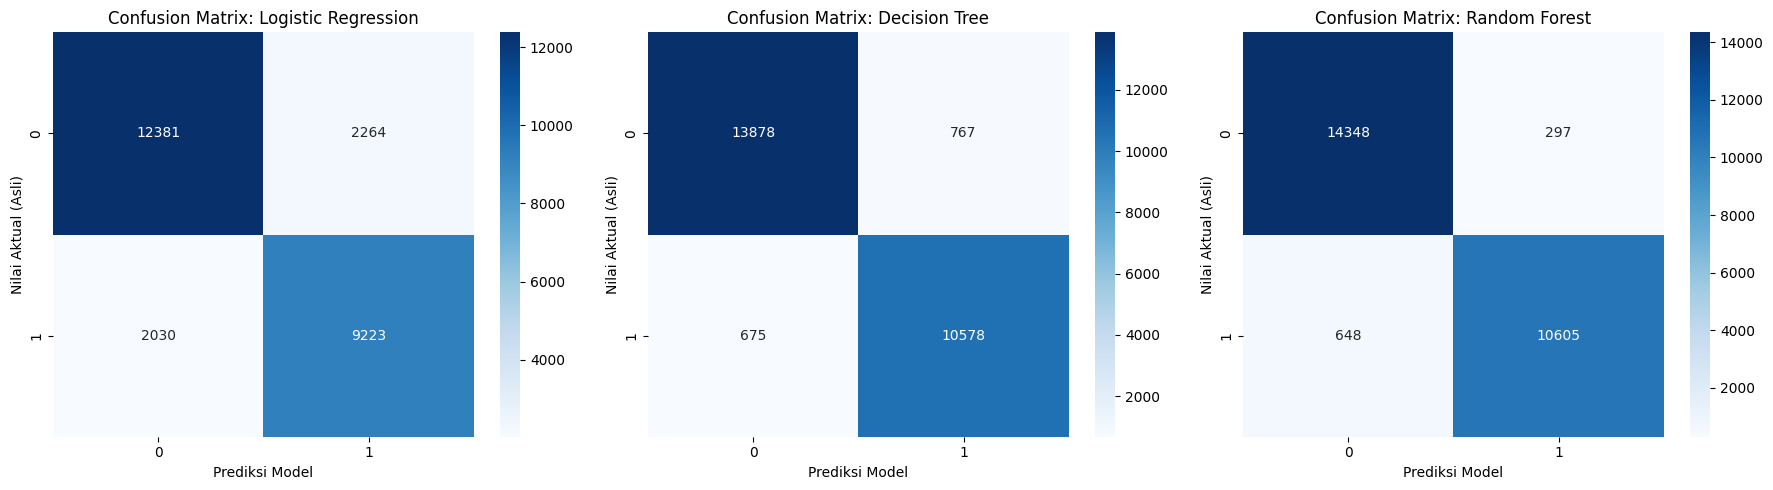


--- Tabel Evaluasi Model Awal ---


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.834196,0.802908,0.819604,0.811170
Decision Tree,0.944320,0.932393,0.940016,0.936189
Random Forest,0.963511,0.972757,0.942415,0.957346


In [ ]:
# Siapkan dictionary untuk menyimpan nilai evaluasi dan canvas untuk gambar
hasil_evaluasi = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Looping untuk melatih dan mengevaluasi ketiga model secara otomatis
for i, (nama_model, model) in enumerate(models.items()):

    # 1. Melatih model dengan data latih
    model.fit(X_train, y_train)

    # 2. Menyuruh model menebak/memprediksi data uji
    y_pred = model.predict(X_test)

    # 3. Menghitung Metrik Evaluasi
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Menyimpan hasil perhitungan ke dalam tabel
    hasil_evaluasi[nama_model] = [acc, prec, rec, f1]

    # 4. Membuat Gambar Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Confusion Matrix: {nama_model}')
    axes[i].set_xlabel('Prediksi Model')
    axes[i].set_ylabel('Nilai Aktual (Asli)')

plt.tight_layout()
plt.show()

# Menampilkan tabel perbandingan metrik evaluasi
df_hasil = pd.DataFrame(hasil_evaluasi, index=['Accuracy', 'Precision', 'Recall', 'F1-Score']).T
print("\n--- Tabel Evaluasi Model Awal ---")
display(df_hasil)

# **3. Data Preparation (Preprocessing Data)!**

3.1 Transformasi Awal (Bobot 6%)

In [ ]:
print("--- 3.1 Transformasi Awal ---")

# Kita buat copy dari dataset ASLI (df), bukan df_baseline yang sudah kita drop barisnya di tahap 2
df_prep = df.copy()

# 1. Menghapus fitur yang tidak relevan
# Kolom 'id' dan 'Unnamed: 0' tidak ada hubungannya dengan kepuasan pelanggan
kolom_sampah = ['Unnamed: 0', 'id']
df_prep = df_prep.drop(columns=[col for col in kolom_sampah if col in df_prep.columns])

# Menghapus 'Departure Delay' untuk menghindari Multikolinearitas
if 'Departure Delay in Minutes' in df_prep.columns:
    df_prep = df_prep.drop(columns=['Departure Delay in Minutes'])
    print("- Kolom 'Departure Delay in Minutes' dihapus karena redundan dengan 'Arrival Delay'.")

# 2. Encoding variabel target
target_col = 'satisfaction' if 'satisfaction' in df_prep.columns else 'Satisfaction'

# Mengubah manual target menjadi biner: 0 untuk tidak puas/netral, 1 untuk puas
df_prep[target_col] = df_prep[target_col].map({'Neutral or Dissatisfied': 0, 'Satisfied': 1})
print("- Target 'satisfaction' berhasil di-encode (0 = neutral/dissatisfied, 1 = satisfied).")

--- 3.1 Transformasi Awal ---
- Target 'satisfaction' berhasil di-encode (0 = neutral/dissatisfied, 1 = satisfied).


3.2 Penanganan Missing Value & Outlier (Bobot 7%)

In [ ]:
import numpy as np

print("--- 3.2 Penanganan Missing Value & Outlier ---")

# 1. Penanganan Missing Value (Imputasi Median)
missing_cols = df_prep.columns[df_prep.isnull().any()].tolist()

for col in missing_cols:
    median_val = df_prep[col].median()
    df_prep[col].fillna(median_val, inplace=True)
    print(f"- Missing value pada kolom '{col}' berhasil diimputasi dengan nilai Median ({median_val}).")

# 2. Analisis & Penanganan Outlier dengan Capping (IQR)
# Kita fokus pada fitur kontinu yang tersisa
fitur_kontinu_prep = ['Flight Distance', 'Arrival Delay in Minutes']
fitur_kontinu_prep = [col for col in fitur_kontinu_prep if col in df_prep.columns]

for col in fitur_kontinu_prep:
    Q1 = df_prep[col].quantile(0.25)
    Q3 = df_prep[col].quantile(0.75)
    IQR = Q3 - Q1

    # Menentukan batas bawah dan atas
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping: Membatasi nilai agar tidak melebihi lower/upper bound
    df_prep[col] = df_prep[col].clip(lower=lower_bound, upper=upper_bound)

print("- Penanganan Outlier selesai menggunakan metode Capping (Batas IQR).")

--- 3.2 Penanganan Missing Value & Outlier ---
- Missing value pada kolom 'Arrival Delay' berhasil diimputasi dengan nilai Median (0.0).
- Missing value pada kolom 'Satisfaction' berhasil diimputasi dengan nilai Median (nan).
- Penanganan Outlier selesai menggunakan metode Capping (Batas IQR).


3.3 Encoding & Scaling (Bobot 7%)

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

print("--- 3.3 Encoding & Scaling ---")

# Memisahkan kembali fitur prediktor (X) dan target (y) dari data yang sudah di-prep
X_bersih = df_prep.drop(columns=[target_col])
y_bersih = df_prep[target_col]

# 1. Encoding Fitur Kategorikal (One-Hot Encoding)
# drop_first=True mencegah dummy variable trap
X_encoded = pd.get_dummies(X_bersih, drop_first=True)
print(f"- Bentuk data setelah Encoding: {X_encoded.shape[1]} kolom fitur.")

# 2. Scaling Data
# Menggunakan StandardScaler agar semua fitur memiliki rata-rata 0 dan standar deviasi 1
scaler = StandardScaler()

# Melakukan scaling dan mengembalikannya dalam bentuk DataFrame Pandas
X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns)

print("- Proses Scaling selesai menggunakan StandardScaler.")
print("\nCuplikan Data yang Sudah Bersih dan Siap Masuk Model:")
display(X_scaled.head())

--- 3.3 Encoding & Scaling ---
- Bentuk data setelah Encoding: 24 kolom fitur.
- Proses Scaling selesai menggunakan StandardScaler.

Cuplikan Data yang Sudah Bersih dan Siap Masuk Model:


,ID,Age,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,...,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Gender_Male,Customer Type_Returning,Type of Travel_Personal,Class_Economy,Class_Economy Plus
0,-1.732037,0.566960,-0.370294,-0.333948,-0.261490,-0.037727,0.173445,0.547894,-0.187037,0.018048,...,1.349867,1.153946,0.204090,1.230787,1.159206,1.014878,-2.112281,-0.669366,-0.902608,-0.279499
1,-1.732011,-0.292868,-0.370294,0.296454,0.623553,-0.692719,-0.539957,-0.241883,1.293662,-0.764109,...,-0.153973,1.153946,-0.548166,1.230787,1.159206,-0.985340,0.473422,-0.669366,-0.902608,-0.279499
2,-1.731984,0.103976,-0.337919,-0.386481,-0.391644,0.617265,0.886847,0.547894,1.293662,0.800206,...,1.349867,-0.545774,0.956346,-0.268414,-0.535681,1.014878,0.473422,-0.669366,-0.902608,-0.279499
3,-1.731957,0.699242,0.726438,-0.386481,-0.391644,-0.692719,-0.539957,-0.241883,0.553313,-0.764109,...,0.597947,1.153946,-0.548166,1.230787,1.159206,1.014878,0.473422,-0.669366,-0.902608,-0.279499
4,-1.731931,0.633101,2.309819,-0.386481,-0.365613,-0.037727,0.173445,-0.241883,1.293662,0.018048,...,0.597947,-0.545774,0.204090,-0.268414,-0.535681,-0.985340,0.473422,-0.669366,-0.902608,-0.279499


# **4. Validasi & Sampling (Imbalance Data)**

4.1 Penanganan Imbalance Class (Bobot 5%)

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

print("--- Memperbaiki Data & Menjalankan 4.1 SMOTE ---")

# 1. KITA RESET & BERSIHKAN DATA ULANG (Lebih aman)
df_prep = df.copy()

# Hapus kolom tidak relevan
kolom_sampah = ['Unnamed: 0', 'id', 'Departure Delay in Minutes']
df_prep = df_prep.drop(columns=[col for col in kolom_sampah if col in df_prep.columns])

# Encode Target (Menggunakan LabelEncoder agar tidak error walau di-run berkali-kali)
target_col = 'satisfaction' if 'satisfaction' in df_prep.columns else 'Satisfaction'
# Hapus baris jika memang targetnya kosong dari dataset asli
df_prep = df_prep.dropna(subset=[target_col])
y_bersih = LabelEncoder().fit_transform(df_prep[target_col])

# Imputasi Median untuk fitur yang kosong
for col in df_prep.columns[df_prep.isnull().any()]:
    df_prep[col].fillna(df_prep[col].median(), inplace=True)

# Outlier Capping (Batas IQR)
for col in ['Flight Distance', 'Arrival Delay in Minutes']:
    if col in df_prep.columns:
        Q1, Q3 = df_prep[col].quantile(0.25), df_prep[col].quantile(0.75)
        df_prep[col] = df_prep[col].clip(lower=Q1 - 1.5*(Q3-Q1), upper=Q3 + 1.5*(Q3-Q1))

# Encoding Fitur (X) & Scaling
X_bersih = df_prep.drop(columns=[target_col])
X_encoded = pd.get_dummies(X_bersih, drop_first=True)
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X_encoded), columns=X_encoded.columns)

print("Data berhasil diperbaiki! Melanjutkan ke proses SMOTE...\n")


# 2. PROSES TAHAP 4.1 (SMOTE)
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_scaled, y_bersih, test_size=0.2, random_state=42, stratify=y_bersih
)

print("Distribusi Kelas pada Data Latih SEBELUM SMOTE:")
# Convert y_train_clean ke Series agar bisa di value_counts
print(pd.Series(y_train_clean).value_counts().rename(index={0: 'Neutral/Dissatisfied (0)', 1: 'Satisfied (1)'}))

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_clean, y_train_clean)

print("\nDistribusi Kelas pada Data Latih SESUDAH SMOTE:")
print(pd.Series(y_train_smote).value_counts().rename(index={0: 'Neutral/Dissatisfied (0)', 1: 'Satisfied (1)'}))

--- Memperbaiki Data & Menjalankan 4.1 SMOTE ---
Data berhasil diperbaiki! Melanjutkan ke proses SMOTE...

Distribusi Kelas pada Data Latih SEBELUM SMOTE:
Neutral/Dissatisfied (0)    58762
Satisfied (1)               45142
Name: count, dtype: int64

Distribusi Kelas pada Data Latih SESUDAH SMOTE:
Satisfied (1)               58762
Neutral/Dissatisfied (0)    58762
Name: count, dtype: int64


4.2 Pemodelan Ulang (Bobot 5%)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("--- 4.2 Pemodelan Ulang ---")

try:
    # A. Melatih model HANYA dengan data Preprocessed (Tanpa SMOTE)
    # Ini akan kita gunakan sebagai pembanding
    print("Sedang melatih model tanpa SMOTE...")
    model_rf_clean = RandomForestClassifier(random_state=42)
    model_rf_clean.fit(X_train_clean, y_train_clean)
    y_pred_clean = model_rf_clean.predict(X_test_clean)
    print("- Model Random Forest (Tanpa SMOTE) berhasil dilatih.")

    # B. Melatih model UTAMA dengan data Preprocessed + SMOTE (Sesuai instruksi)
    print("Sedang melatih model dengan SMOTE (mungkin memakan waktu sedikit lebih lama)...")
    model_rf_smote = RandomForestClassifier(random_state=42)
    model_rf_smote.fit(X_train_smote, y_train_smote)
    y_pred_smote = model_rf_smote.predict(X_test_clean)
    print("- Model Random Forest (Dengan SMOTE) berhasil dilatih.")

    print("\nPemodelan ulang selesai! Semua prediksi sudah disimpan dan siap dievaluasi.")

except NameError:
    print("ERROR: Variabel data latih tidak ditemukan.")
    print("SOLUSI: Pastikan Anda sudah menjalankan kode 4.1 yang saya berikan sebelumnya.")

--- 4.2 Pemodelan Ulang ---
Sedang melatih model tanpa SMOTE...
- Model Random Forest (Tanpa SMOTE) berhasil dilatih.
Sedang melatih model dengan SMOTE (mungkin memakan waktu sedikit lebih lama)...
- Model Random Forest (Dengan SMOTE) berhasil dilatih.

Pemodelan ulang selesai! Semua prediksi sudah disimpan dan siap dievaluasi.


4.3 Evaluasi Sampling (Bobot 5%)

In [ ]:
print("--- 4.3 Evaluasi Sampling (Fokus Kelas 'Satisfied' / 1) ---")

# Mendapatkan report klasifikasi dalam bentuk dictionary
report_clean = classification_report(y_test_clean, y_pred_clean, output_dict=True)
report_smote = classification_report(y_test_clean, y_pred_smote, output_dict=True)

# Membuat tabel perbandingan khusus untuk kelas 1 ('Satisfied')
eval_43 = pd.DataFrame({
    "Sebelum SMOTE (Hanya Preprocessing)": [report_clean['1']['precision'], report_clean['1']['recall'], report_clean['1']['f1-score']],
    "Sesudah SMOTE (+ Preprocessing)": [report_smote['1']['precision'], report_smote['1']['recall'], report_smote['1']['f1-score']]
}, index=['Precision', 'Recall', 'F1-Score'])

print("Perbandingan Evaluasi Khusus Penumpang 'Satisfied':")
display(eval_43)

--- 4.3 Evaluasi Sampling (Fokus Kelas 'Satisfied' / 1) ---
Perbandingan Evaluasi Khusus Penumpang 'Satisfied':


,Sebelum SMOTE (Hanya Preprocessing),Sesudah SMOTE (+ Preprocessing)
Precision,0.974872,0.972828
Recall,0.941875,0.945330
F1-Score,0.958089,0.958882


4.4 Bandingkan Direct Modeling dengan Oversampling + Preprocessing (Bobot 5%)

In [ ]:
print("--- 4.4 Bandingkan Direct Modeling vs Preprocessing+SMOTE ---")

# Menghitung metrik akhir untuk model kita saat ini (Tahap 4)
acc_final = accuracy_score(y_test_clean, y_pred_smote)
prec_final = precision_score(y_test_clean, y_pred_smote)
rec_final = recall_score(y_test_clean, y_pred_smote)
f1_final = f1_score(y_test_clean, y_pred_smote)

try:
    # Mengambil nilai model Random Forest mentah dari Tahap 2 (variabel hasil_evaluasi)
    acc_baseline = hasil_evaluasi['Random Forest'][0]
    prec_baseline = hasil_evaluasi['Random Forest'][1]
    rec_baseline = hasil_evaluasi['Random Forest'][2]
    f1_baseline = hasil_evaluasi['Random Forest'][3]

    # Membuat tabel perbandingan keseluruhan
    eval_44 = pd.DataFrame({
        "Direct Modeling Mentah (Tahap 2)": [acc_baseline, prec_baseline, rec_baseline, f1_baseline],
        "Model Bersih + SMOTE (Tahap 4)": [acc_final, prec_final, rec_final, f1_final]
    }, index=['Accuracy', 'Precision', 'Recall', 'F1-Score'])

    print("Hasil Pembuktian Performa Keseluruhan:")
    display(eval_44)

except NameError:
    print("Variabel hasil evaluasi dari Tahap 2 tidak ditemukan di memori. Pastikan Anda sudah menjalankan cell Tahap 2.4 sebelumnya.")

--- 4.4 Bandingkan Direct Modeling vs Preprocessing+SMOTE ---
Hasil Pembuktian Performa Keseluruhan:


,Direct Modeling Mentah (Tahap 2),Model Bersih + SMOTE (Tahap 4)
Accuracy,0.963511,0.964775
Precision,0.972757,0.972828
Recall,0.942415,0.945330
F1-Score,0.957346,0.958882


# **5. Hyperparameter Tuning & Feature Selection (Optimasi).**

5.1 Feature Selection (Bobot 7%)

--- 5.1 Feature Selection (Feature Importance) ---


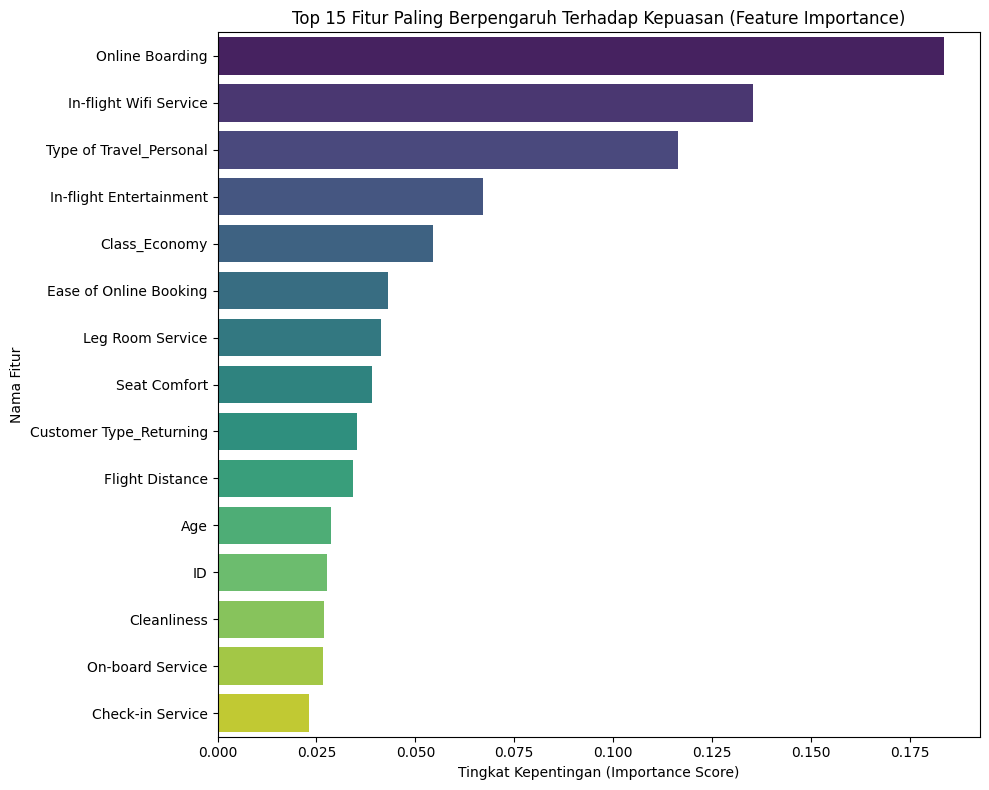

Analisis:
Fitur yang berada di urutan teratas adalah aspek yang paling harus diperhatikan oleh manajemen maskapai untuk meningkatkan kepuasan pelanggan.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 5.1 Feature Selection (Feature Importance) ---")

# Mengambil nilai kepentingan fitur dari model Random Forest yang dibuat di Tahap 4
importances = model_rf_smote.feature_importances_
fitur_names = X_train_smote.columns

# Membuat DataFrame agar mudah diurutkan dan divisualisasikan
df_importance = pd.DataFrame({'Fitur': fitur_names, 'Tingkat Kepentingan': importances})
df_importance = df_importance.sort_values(by='Tingkat Kepentingan', ascending=False)

# Visualisasi Top 15 Fitur Paling Berpengaruh
plt.figure(figsize=(10, 8))
sns.barplot(x='Tingkat Kepentingan', y='Fitur', data=df_importance.head(15), palette='viridis')
plt.title('Top 15 Fitur Paling Berpengaruh Terhadap Kepuasan (Feature Importance)')
plt.xlabel('Tingkat Kepentingan (Importance Score)')
plt.ylabel('Nama Fitur')
plt.tight_layout()
plt.show()

print("Analisis:")
print("Fitur yang berada di urutan teratas adalah aspek yang paling harus diperhatikan oleh manajemen maskapai untuk meningkatkan kepuasan pelanggan.")

5.2 Hyperparameter Tuning (Bobot 7%)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

print("--- 5.2 Hyperparameter Tuning ---")

# 1. Mendefinisikan ruang parameter yang akan diuji-coba oleh komputer
param_dist = {
    'n_estimators': [50, 100, 200],      # Jumlah pohon di hutan (Random Forest)
    'max_depth': [10, 20, None],         # Kedalaman maksimal pohon
    'min_samples_split': [2, 5, 10],     # Minimal jumlah sampel untuk memecah node
    'min_samples_leaf': [1, 2, 4]        # Minimal jumlah sampel di ujung daun
}

# 2. Menggunakan Randomized Search
# n_iter=5 berarti komputer akan mencoba 5 kombinasi acak dari param_dist di atas.
# (Bisa dinaikkan jika punya spesifikasi laptop tinggi/waktu luang)
rf_tune = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(estimator=rf_tune, param_distributions=param_dist,
                                   n_iter=5, cv=3, scoring='accuracy', random_state=42, n_jobs=-1)

# 3. Melatih model untuk mencari parameter terbaik (Menggunakan data SMOTE dari Tahap 4)
print("Sedang mencari parameter terbaik... (Ini mungkin memakan waktu 1-3 menit, harap tunggu!)")
random_search.fit(X_train_smote, y_train_smote)

# 4. Menyimpan model dengan parameter terbaik
best_rf_model = random_search.best_estimator_

print("\nHyperparameter Tuning Selesai!")
print(f"Kombinasi Parameter Terbaik yang Ditemukan: {random_search.best_params_}")

--- 5.2 Hyperparameter Tuning ---
Sedang mencari parameter terbaik... (Ini mungkin memakan waktu 1-3 menit, harap tunggu!)

Hyperparameter Tuning Selesai!
Kombinasi Parameter Terbaik yang Ditemukan: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}


5.3 Visualisasi Perbandingan (Bobot 6%)

--- 5.3 Visualisasi Perbandingan (Sebelum vs Sesudah Optimasi) ---


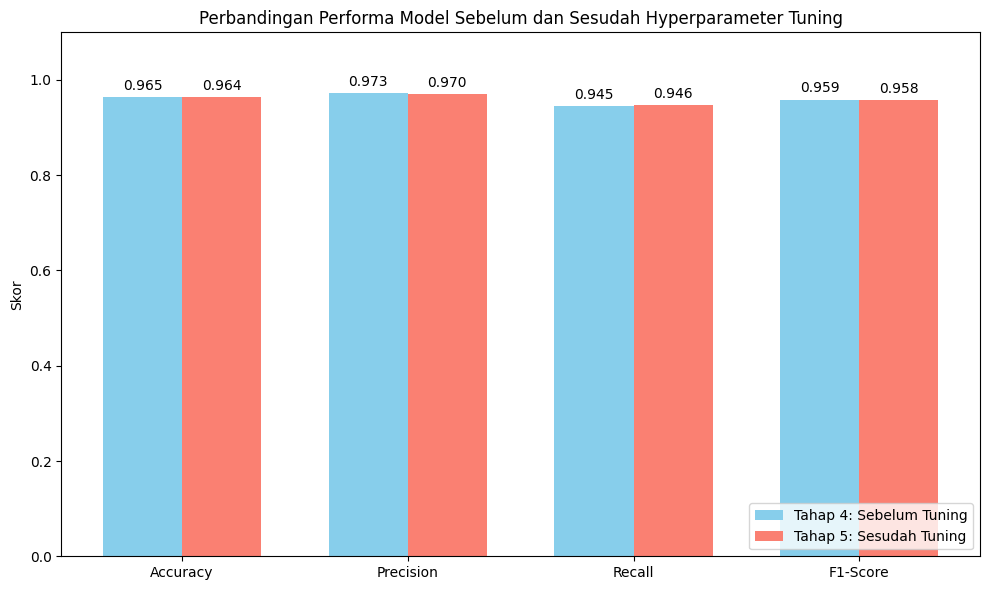

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

print("--- 5.3 Visualisasi Perbandingan (Sebelum vs Sesudah Optimasi) ---")

# 1. Meminta model hasil tuning untuk memprediksi data uji
y_pred_tuned = best_rf_model.predict(X_test_clean)

# 2. Menghitung metrik model tuning
acc_tuned = accuracy_score(y_test_clean, y_pred_tuned)
prec_tuned = precision_score(y_test_clean, y_pred_tuned)
rec_tuned = recall_score(y_test_clean, y_pred_tuned)
f1_tuned = f1_score(y_test_clean, y_pred_tuned)

# 3. Menyiapkan data untuk divisualisasikan
# Nilai acc_final dll berasal dari variabel di Poin 4.4 sebelumnya
metrik_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
skor_sebelum_tuning = [acc_final, prec_final, rec_final, f1_final]
skor_sesudah_tuning = [acc_tuned, prec_tuned, rec_tuned, f1_tuned]

# 4. Membuat Grouped Bar Chart
x = np.arange(len(metrik_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, skor_sebelum_tuning, width, label='Tahap 4: Sebelum Tuning', color='skyblue')
rects2 = ax.bar(x + width/2, skor_sesudah_tuning, width, label='Tahap 5: Sesudah Tuning', color='salmon')

# 5. Menambahkan label dan judul
ax.set_ylabel('Skor')
ax.set_title('Perbandingan Performa Model Sebelum dan Sesudah Hyperparameter Tuning')
ax.set_xticks(x)
ax.set_xticklabels(metrik_labels)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1)

# Menambahkan angka detail di atas tiap batang
for bars in [rects1, rects2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()